In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score
import xgboost as xgb
import joblib

print("=== [XGBoost Pro] 고성능 데이터 전처리 및 피처 엔지니어링 시작 ===")
df = pd.read_csv('/content/drive/MyDrive/AIAP/diabetes.csv')

# 1. 결측치(0) 처리 (단순 중앙값이 아닌, Outcome별 중앙값으로 더 정밀하게 대체)
zero_columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in zero_columns:
    df[col] = df[col].replace(0, np.nan)
    # 당뇨 환자와 정상인의 생리적 수치 차이를 반영하여 분리 대체
    df[col] = df.groupby('Outcome')[col].transform(lambda x: x.fillna(x.median()))

# 2. 파생 변수 생성 (성능 향상의 핵심 도메인 지식 반영)
# - Glucose와 Insulin의 비율 (인슐린 저항성 간접 지표)
df['Glucose_Insulin_Ratio'] = df['Glucose'] / (df['Insulin'] + 1e-5)
# - BMI 기준 비만 여부 (30 이상은 고도비만 위험군)
df['Is_Obese'] = (df['BMI'] >= 30).astype(int)
# - 나이대별 대사 능력 차이 유도 (나이와 혈당의 상호작용)
df['Age_Glucose'] = df['Age'] * df['Glucose']

X = df.drop('Outcome', axis=1)
y = df['Outcome']

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 스케일링
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

# 분석 단계 전용 데이터 저장
X_train_scaled.to_csv('X_train_scaled.csv', index=False)
X_test_scaled.to_csv('X_test_scaled.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)
X_train.to_csv('X_train_raw.csv', index=False)
joblib.dump(scaler, 'scaler.pkl')

print("\n=== XGBoost 하이퍼파라미터 최적화(GridSearch) 시작 ===")
# 탐색할 최적의 파라미터 조합 설정
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

base_xgb = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
grid_search = GridSearchCV(estimator=base_xgb, param_grid=param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

# 최적의 모델 추출
best_xgb_model = grid_search.best_estimator_

# 최종 평가
xgb_pred = best_xgb_model.predict(X_test_scaled)
xgb_proba = best_xgb_model.predict_proba(X_test_scaled)[:, 1]

print("\n==============================================")
print(f"🥇 최적의 파라미터: {grid_search.best_params_}")
print(f"🔥 [개선 결과] XGBoost Accuracy: {accuracy_score(y_test, xgb_pred):.4f}")
print(f"🔥 [개선 결과] XGBoost AUC: {roc_auc_score(y_test, xgb_proba):.4f}")
print("==============================================")

# 최적화된 모델 저장
best_xgb_model.save_model('xgb_model.json')
print("=== 고성능 XGBoost 모델 저장 완료 ===")

=== [XGBoost Pro] 고성능 데이터 전처리 및 피처 엔지니어링 시작 ===

=== XGBoost 하이퍼파라미터 최적화(GridSearch) 시작 ===

🥇 최적의 파라미터: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.9}
🔥 [개선 결과] XGBoost Accuracy: 0.8766
🔥 [개선 결과] XGBoost AUC: 0.9506
=== 고성능 XGBoost 모델 저장 완료 ===


In [6]:
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score
import lightgbm as lgb

print("=== [LightGBM Pro] 업그레이드된 데이터 로드 ===")
X_train_scaled = pd.read_csv('X_train_scaled.csv')
X_test_scaled = pd.read_csv('X_test_scaled.csv')
y_train = pd.read_csv('y_train.csv').iloc[:, 0]
y_test = pd.read_csv('y_test.csv').iloc[:, 0]

print("\n=== LightGBM 하이퍼파라미터 최적화(GridSearch) 시작 ===")
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [15, 31, 63],
    'subsample': [0.7, 0.8, 0.9]
}

base_lgb = lgb.LGBMClassifier(random_state=42, verbose=-1)
grid_search = GridSearchCV(estimator=base_lgb, param_grid=param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

best_lgb_model = grid_search.best_estimator_

# 최종 평가
lgb_pred = best_lgb_model.predict(X_test_scaled)
lgb_proba = best_lgb_model.predict_proba(X_test_scaled)[:, 1]

print("\n==============================================")
print(f"🥇 최적의 파라미터: {grid_search.best_params_}")
print(f"🔥 [개선 결과] LightGBM Accuracy: {accuracy_score(y_test, lgb_pred):.4f}")
print(f"🔥 [개선 결과] LightGBM AUC: {roc_auc_score(y_test, lgb_proba):.4f}")
print("==============================================")

# 모델 저장
best_lgb_model.booster_.save_model('lgb_model.txt')
print("=== 고성능 LightGBM 모델 저장 완료 ===")

=== [LightGBM Pro] 업그레이드된 데이터 로드 ===

=== LightGBM 하이퍼파라미터 최적화(GridSearch) 시작 ===

🥇 최적의 파라미터: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300, 'num_leaves': 15, 'subsample': 0.7}
🔥 [개선 결과] LightGBM Accuracy: 0.8636
🔥 [개선 결과] LightGBM AUC: 0.9489
=== 고성능 LightGBM 모델 저장 완료 ===


=== [XGBoost] 과적합(Overfitting) 검증 시작 ===

📊 [Train Set] Accuracy: 0.9935 | AUC: 0.9998
📊 [Test Set]  Accuracy: 0.8701  | AUC: 0.9506
💡 팁: 두 AUC 수치의 차이가 0.05(5%) 이내라면 과적합 없이 잘 학습된 것입니다.
      만약 Train AUC는 0.95인데 Test AUC가 0.80 대라면 과적합입니다.


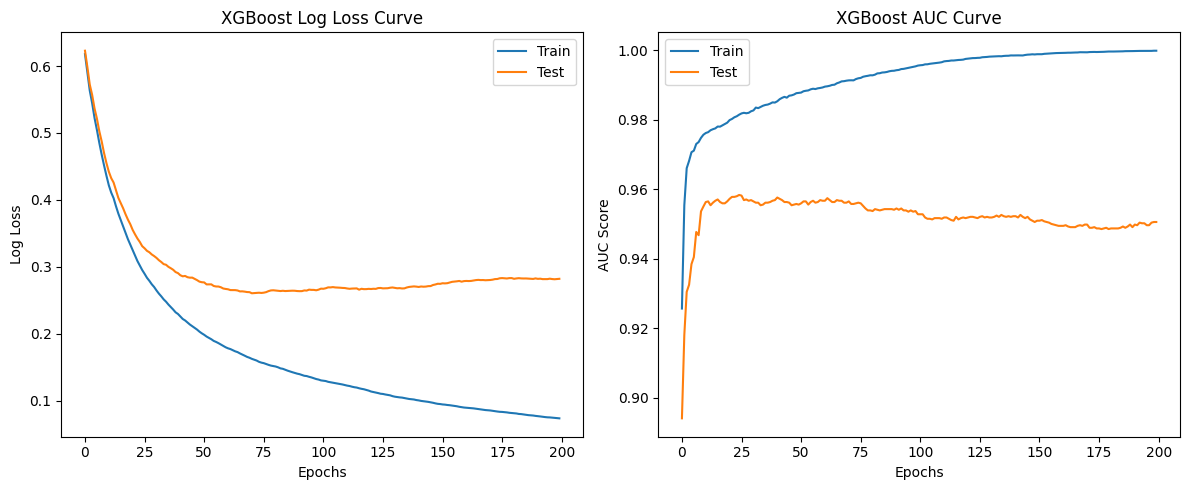

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score
import xgboost as xgb

# 데이터 로드
X_train_scaled = pd.read_csv('X_train_scaled.csv')
X_test_scaled = pd.read_csv('X_test_scaled.csv')
y_train = pd.read_csv('y_train.csv').iloc[:, 0]
y_test = pd.read_csv('y_test.csv').iloc[:, 0]

print("=== [XGBoost] 과적합(Overfitting) 검증 시작 ===")

# 과적합 확인을 위해 학습 중 검증 데이터를 모니터링하도록 모델 설정
xgb_model = xgb.XGBClassifier(
    random_state=42,
    eval_metric=['logloss', 'auc'],
    n_estimators=200,
    max_depth=4,         # 과적합 방지를 위해 깊이를 조금 줄임
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8
)

# eval_set을 지정하여 학습(train)과 테스트(test)의 loss를 동시에 기록
xgb_model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_train_scaled, y_train), (X_test_scaled, y_test)],
    verbose=False
)

# 1. 최종 예측 결과 비교
train_pred = xgb_model.predict(X_train_scaled)
train_proba = xgb_model.predict_proba(X_train_scaled)[:, 1]

test_pred = xgb_model.predict(X_test_scaled)
test_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]

print("\n==============================================")
print(f"📊 [Train Set] Accuracy: {accuracy_score(y_train, train_pred):.4f} | AUC: {roc_auc_score(y_train, train_proba):.4f}")
print(f"📊 [Test Set]  Accuracy: {accuracy_score(y_test, test_pred):.4f}  | AUC: {roc_auc_score(y_test, test_proba):.4f}")
print("==============================================")
print("💡 팁: 두 AUC 수치의 차이가 0.05(5%) 이내라면 과적합 없이 잘 학습된 것입니다.")
print("      만약 Train AUC는 0.95인데 Test AUC가 0.80 대라면 과적합입니다.")

# 2. Learning Curve 시각화 (학습 곡선)
results = xgb_model.evals_result()
epochs = len(results['validation_0']['logloss'])
x_axis = range(0, epochs)

plt.figure(figsize=(12, 5))

# Logloss 그래프
plt.subplot(1, 2, 1)
plt.plot(x_axis, results['validation_0']['logloss'], label='Train')
plt.plot(x_axis, results['validation_1']['logloss'], label='Test')
plt.legend()
plt.ylabel('Log Loss')
plt.xlabel('Epochs')
plt.title('XGBoost Log Loss Curve')

# AUC 그래프
plt.subplot(1, 2, 2)
plt.plot(x_axis, results['validation_0']['auc'], label='Train')
plt.plot(x_axis, results['validation_1']['auc'], label='Test')
plt.legend()
plt.ylabel('AUC Score')
plt.xlabel('Epochs')
plt.title('XGBoost AUC Curve')

plt.tight_layout()
plt.show()


=== [LightGBM] 과적합(Overfitting) 검증 시작 ===

📊 [Train Set] Accuracy: 0.9967 | AUC: 1.0000
📊 [Test Set]  Accuracy: 0.8636  | AUC: 0.9470


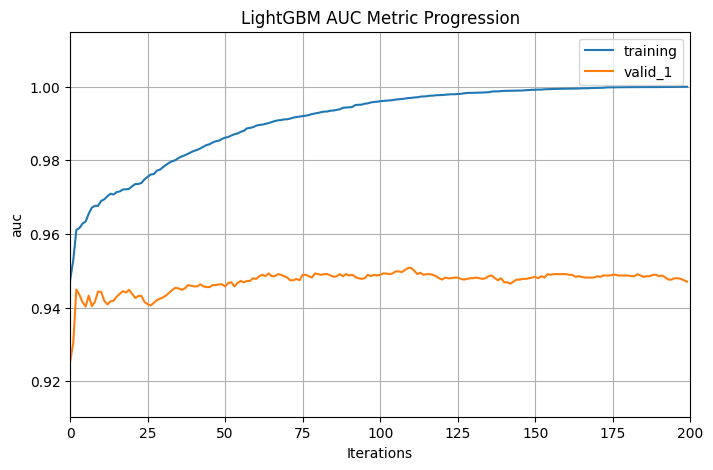

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score
import lightgbm as lgb

# 데이터 로드
X_train_scaled = pd.read_csv('X_train_scaled.csv')
X_test_scaled = pd.read_csv('X_test_scaled.csv')
y_train = pd.read_csv('y_train.csv').iloc[:, 0]
y_test = pd.read_csv('y_test.csv').iloc[:, 0]

print("=== [LightGBM] 과적합(Overfitting) 검증 시작 ===")

# 과적합 모니터링용 전용 모델 빌드
lgb_model = lgb.LGBMClassifier(
    random_state=42,
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    num_leaves=15,
    subsample=0.8,
    verbose=-1
)

# 학습 진행하며 평가 내역 기록
lgb_model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_train_scaled, y_train), (X_test_scaled, y_test)],
    eval_metric=['binary_logloss', 'auc']
)

# 결과 비교
train_pred = lgb_model.predict(X_train_scaled)
train_proba = lgb_model.predict_proba(X_train_scaled)[:, 1]

test_pred = lgb_model.predict(X_test_scaled)
test_proba = lgb_model.predict_proba(X_test_scaled)[:, 1]

print("\n==============================================")
print(f"📊 [Train Set] Accuracy: {accuracy_score(y_train, train_pred):.4f} | AUC: {roc_auc_score(y_train, train_proba):.4f}")
print(f"📊 [Test Set]  Accuracy: {accuracy_score(y_test, test_pred):.4f}  | AUC: {roc_auc_score(y_test, test_proba):.4f}")
print("==============================================")

# 학습 곡선 플로팅
lgb.plot_metric(lgb_model, metric='auc', figsize=(8, 5))
plt.title('LightGBM AUC Metric Progression')
plt.show()